In [1]:
print("Hi")

Hi


In [2]:
import torch 
from torch import nn

import matplotlib.pyplot as plt

In [3]:
torch.__version__

'2.11.0+cpu'

In [4]:
# 1.Data (preparing and Loading)



In [5]:
# Create *know* parameters
weight = 0.7
bias =0.3 

# Create 
start =0
end=1
step = 0.02

x= torch.arange(start , end , step).unsqueeze(dim=1)
y=weight * x + bias

x[:10] , y[:10] , len(x) , len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [6]:
len(x) , len(y)

(50, 50)

In [7]:
!pip install scikit-learn

In [8]:
## splitting our data  into training and test sets
from sklearn.model_selection import train_test_split

X_train , X_test , Y_train , Y_test = train_test_split(x , y , test_size=0.2 ,random_state=42)


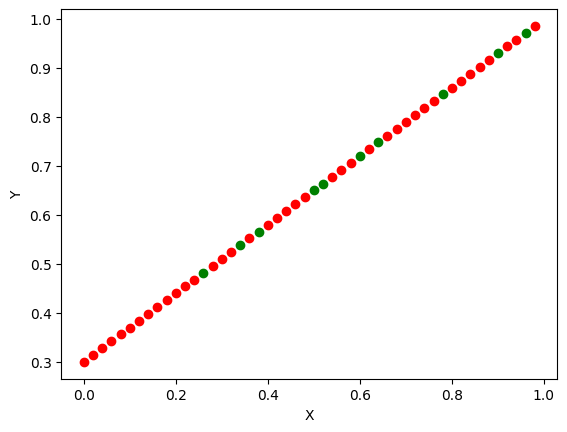

In [9]:
plt.scatter(X_train , Y_train , color="Red")
plt.scatter(X_test , Y_test , color="Green")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [10]:
# nn.Linear() -> nn.Linaer( in_feature,out_feature ,bias=True)
x = torch.randn(3, 25, 25)   # (C, H, W)
x_flat = x.flatten()          # or x.view(-1) → shape: (1875,)

in_features = 3 * 25 * 25     # = 1875
layer = nn.Linear(in_features=1875, out_features=10)

y = layer(x_flat)             # shape: (10,)

In [11]:
# Basic Linear regreesion model 

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features = 1 , out_features= 1 , bias=True)

    def forward(self , x):
        return self.linear(x)


##  nn.Linear is a class, and self.linear is an instance of 
# that class — not a function. But in Python, any object becomes "callable" (usable with () syntax) if its class 
# defines a special method called __call__. nn.Module (the parent class of nn.Linear, and of your LinearRegression class too) defines exactly that.


model = LinearRegression()

criteria = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters() , lr=0.01)

epochs = 30

for epoch in range(epochs):

    y_pred = model(X_train)
    loss = criteria(y_pred , Y_train)

    #Backward 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    
w, b = model.linear.weight.item(), model.linear.bias.item()
print(f"\nLearned: y = {w:.2f}x + {b:.2f}")




Epoch 20/30, Loss: 0.8005

Learned: y = 0.48x + -0.28


In [12]:
# Unlike in the tensorflow in pytorch we have to write all code ourself

torch.manual_seed(0)

# Level 1 - ONe gaint batch()

X= torch.linspace(0 , 10 , 200).reshape(-1 , 1)
y= 2*X +1 + torch.randn(200 , 1)*0.5


model = nn.Linear(in_features= 1 , out_features=1 , bias = True)
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(model.parameters() , lr=0.01)

for epoch in range(50):
    y_pred = model(X) # forward pass bulds a computation graph as it runs

    loss = criterion(y_pred , y) # nn.L1loss() 

    optimizer.zero_grad() 
    loss.backward()
    optimizer.step()

    if (epoch+1)%10==0 : print(f"the model weight {[model.weight.item()]} and gradients {[model.weight.grad]}")

w , b = model.weight.item() , model.bias.item()
print(w , b)

the model weight [-0.6822052001953125] and gradients [tensor([[-5.0000]])]
the model weight [-0.5822052955627441] and gradients [tensor([[-5.0000]])]
the model weight [-0.4822053909301758] and gradients [tensor([[-5.0000]])]
the model weight [-0.3822054862976074] and gradients [tensor([[-5.0000]])]
the model weight [-0.28220558166503906] and gradients [tensor([[-5.0000]])]
-0.28220558166503906 -0.024131596088409424


In [13]:
# Level -2 - Manual mini batches 
## This is the important conceptual step : before you use DataLoder, understand what it is automating

batch_size = 32
n_samples= X.shape[0]

for epoch in range(50):

    permutation = torch.randperm(n_samples)

    epoch_loss = 0.0

    for i in range(0 , n_samples , batch_size):
        indices = permutation[i : i+ batch_size]
        X_batch , y_batch = X[indices] , y[indices]

        y_pred = model(X_batch)
        loss = criterion(y_pred , y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()*len(indices)

    epoch_loss /= n_samples
    if (epoch+1)%5==0 :print(f"Epoch : {epoch+1} : loss={epoch_loss:.4f}")



Epoch : 5 : loss=10.5946
Epoch : 10 : loss=8.5178
Epoch : 15 : loss=6.4142
Epoch : 20 : loss=4.3880
Epoch : 25 : loss=2.4022
Epoch : 30 : loss=0.7762
Epoch : 35 : loss=0.4982
Epoch : 40 : loss=0.4733
Epoch : 45 : loss=0.4500
Epoch : 50 : loss=0.4272


In [14]:
from torch.utils.data import TensorDataset , DataLoader

dataset = TensorDataset(X, y)
loader = DataLoader(dataset , batch_size = 32 , shuffle=True)

for epoch in range(50):
    epoch_loss=0.0
    for X_batch , y_batch in loader:
        y_pred= model(X_batch)

        loss = criterion(y_pred , y_batch)
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()*X_batch.size(0)

    epoch_loss /=len(dataset)
    if (epoch+1)%5==0 :print(f"Epoch {epoch+1} : loss = {epoch_loss : .4f}")
    

Epoch 5 : loss =  0.4125
Epoch 10 : loss =  0.3989
Epoch 15 : loss =  0.3904
Epoch 20 : loss =  0.3849
Epoch 25 : loss =  0.3822
Epoch 30 : loss =  0.3792
Epoch 35 : loss =  0.3770
Epoch 40 : loss =  0.3765
Epoch 45 : loss =  0.3743
Epoch 50 : loss =  0.3760


In [15]:
X = torch.linspace(0 , 10 , 100).reshape(-1 , 1)
y = 2*X + 1 + torch.randn(100 , 1)*0.5


X_train , X_val , y_train ,y_val = train_test_split(X.numpy() , y.numpy() , test_size=0.2 , random_state=42)

X_train , X_val = torch.tensor(X_train , dtype = torch.float32) , torch.tensor(X_val , dtype=torch.float32)
y_train , y_val = torch.tensor(y_train , dtype = torch.float32) , torch.tensor(y_val , dtype= torch.float32)


train_loader = DataLoader(TensorDataset(X_train , y_train) , batch_size =32 ,shuffle=True)
val_loader = DataLoader(TensorDataset(X_val , y_val) , batch_size = 32 , shuffle=False) 

model = nn.Linear(in_features=1 , out_features=1)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters() , lr=0.01)

epochs=100

for epoch in (range(epochs)):

    model.train()
    train_loss=0.0

    for X_batch , y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred , y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += (loss.item())*(len(X_batch))
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss=0.0
    with torch.no_grad():
        for X_batch , y_batch in val_loader:
            y_pred = model(X_batch)
            loss  = criterion(y_pred , y_batch)

            val_loss += (loss.item())*(len(X_batch))
    val_loss /= len(val_loader.dataset)

    if (epoch+1)%5==0 : print(f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

w, b = model.weight.item(), model.bias.item()

print(f" the weight {w} , and the bais {b}")

     





Epoch 5/100 - loss: 6.6705 - val_loss: 5.7952
Epoch 10/100 - loss: 5.7653 - val_loss: 4.9873
Epoch 15/100 - loss: 4.8757 - val_loss: 4.2160
Epoch 20/100 - loss: 4.0012 - val_loss: 3.4484
Epoch 25/100 - loss: 3.1345 - val_loss: 2.6983
Epoch 30/100 - loss: 2.2794 - val_loss: 1.9685
Epoch 35/100 - loss: 1.4950 - val_loss: 1.2956
Epoch 40/100 - loss: 0.9110 - val_loss: 0.8092
Epoch 45/100 - loss: 0.6423 - val_loss: 0.6132
Epoch 50/100 - loss: 0.6027 - val_loss: 0.6261
Epoch 55/100 - loss: 0.5846 - val_loss: 0.5962
Epoch 60/100 - loss: 0.5700 - val_loss: 0.5654
Epoch 65/100 - loss: 0.5572 - val_loss: 0.5454
Epoch 70/100 - loss: 0.5418 - val_loss: 0.5309
Epoch 75/100 - loss: 0.5274 - val_loss: 0.5141
Epoch 80/100 - loss: 0.5135 - val_loss: 0.4920
Epoch 85/100 - loss: 0.5001 - val_loss: 0.4743
Epoch 90/100 - loss: 0.4868 - val_loss: 0.4559
Epoch 95/100 - loss: 0.4727 - val_loss: 0.4323
Epoch 100/100 - loss: 0.4599 - val_loss: 0.4194
 the weight 1.950850486755371 , and the bais 1.4208449125289

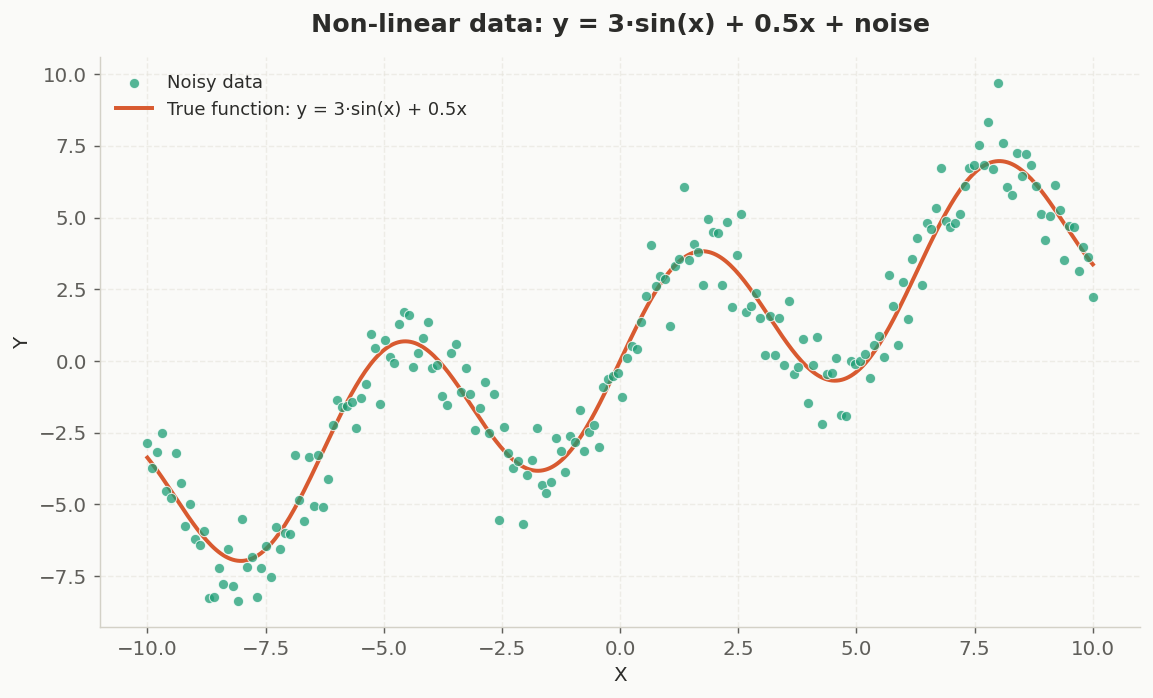

Generated 200 samples. First 5 X values: [-10.          -9.89949749  -9.79899497  -9.69849246  -9.59798995]
First 5 y values: [-2.871 -3.717 -3.155 -2.515 -4.516]


In [16]:
## Let's make a model 

import numpy as np
# ----------------------------------------------------------------------
# 1. Generate the non-linear data
# ----------------------------------------------------------------------
np.random.seed(42)

X = np.linspace(-10, 10, 200)
noise = np.random.normal(loc=0, scale=1.0, size=X.shape)
y = 3 * np.sin(X) + 0.5 * X + noise          # <-- the non-linear equation

# a smooth, noise-free version of the same function, for reference
X_smooth = np.linspace(-10, 10, 400)
y_true = 3 * np.sin(X_smooth) + 0.5 * X_smooth

# ----------------------------------------------------------------------
# 2. "Nice" styling — soft palette, clean spines, subtle grid
# ----------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "#FAFAF8",
    "axes.facecolor": "#FAFAF8",
    "axes.edgecolor": "#D3D1C7",
    "axes.labelcolor": "#2C2C2A",
    "text.color": "#2C2C2A",
    "xtick.color": "#5F5E5A",
    "ytick.color": "#5F5E5A",
    "font.size": 11,
    "grid.color": "#E5E3DA",
    "grid.linewidth": 0.8,
})

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=130)

# noisy data points
ax.scatter(
    X, y,
    s=32, color="#1D9E75", alpha=0.75,
    edgecolor="white", linewidth=0.6,
    label="Noisy data", zorder=3,
)

# true underlying function, for comparison
ax.plot(
    X_smooth, y_true,
    color="#D85A30", linewidth=2.2,
    label="True function: y = 3·sin(x) + 0.5x", zorder=2,
)

ax.set_title("Non-linear data: y = 3·sin(x) + 0.5x + noise", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.grid(True, linestyle="--", alpha=0.6, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=10, loc="upper left")

plt.tight_layout()
plt.show()

print(f"Generated {len(X)} samples. First 5 X values: {X[:5]}")
print(f"First 5 y values: {np.round(y[:5], 3)}")


Epoch 10/100 - Loss: 3.1585 - Val Loss: 2.9104
Epoch 20/100 - Loss: 3.0877 - Val Loss: 2.8236
Epoch 30/100 - Loss: 3.1182 - Val Loss: 3.8770
Epoch 40/100 - Loss: 2.7073 - Val Loss: 2.5682
Epoch 50/100 - Loss: 2.8368 - Val Loss: 2.8084
Epoch 60/100 - Loss: 2.4475 - Val Loss: 2.8973
Epoch 70/100 - Loss: 2.5436 - Val Loss: 2.5156
Epoch 80/100 - Loss: 2.5612 - Val Loss: 2.5065
Epoch 90/100 - Loss: 2.4444 - Val Loss: 2.5918
Epoch 100/100 - Loss: 2.4176 - Val Loss: 2.8380

Test Results
------------------------------
Test Loss : 2.4570
MAE       : 2.4570
MSE       : 11.4497
RMSE      : 3.3837


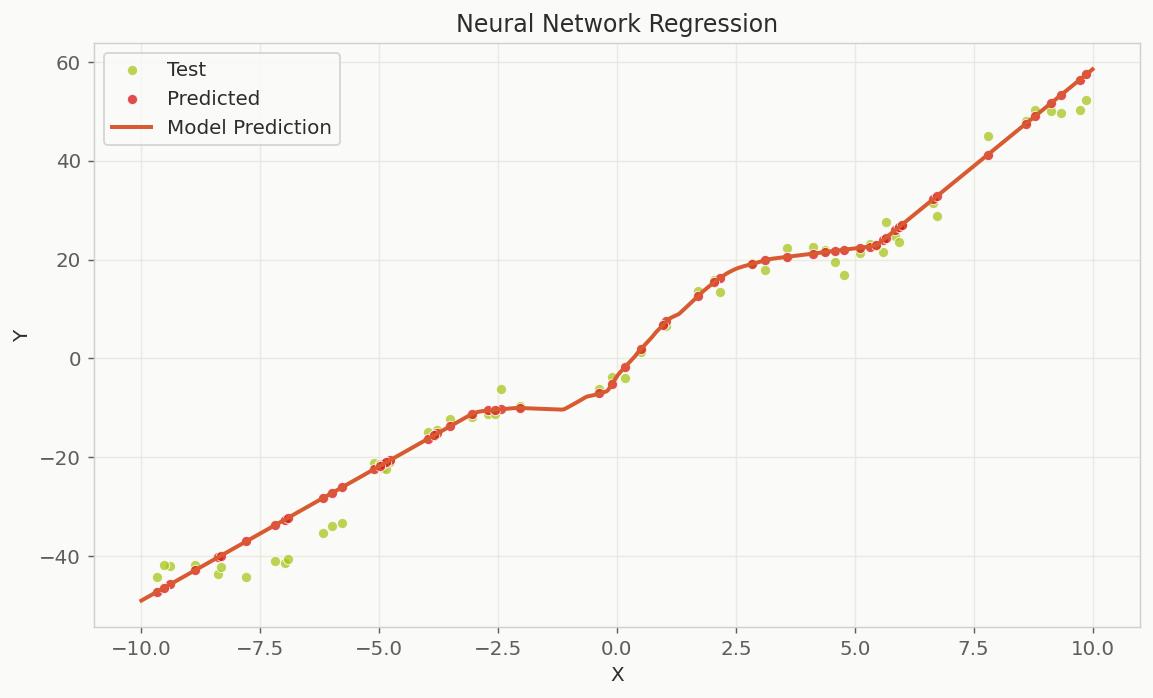

In [17]:



# --------------------------------------------------
# 1. Reproducibility
# --------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)


# --------------------------------------------------
# 2. Create dataset
# --------------------------------------------------
x = np.linspace(-10, 10, 300)

noise = np.random.normal(
    loc=0,
    scale=2.0,
    size=x.shape
)

y = 3 * np.sin(x) + 5 * x - 4 * np.cos(x) + noise


# Convert to PyTorch tensors
X = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
Y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)


# --------------------------------------------------
# 3. Train / Validation / Test split
# --------------------------------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X.numpy(),
    Y.numpy(),
    test_size=0.2,
    random_state=42
)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------------
# 4. Convert back to tensors
# --------------------------------------------------
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)


X_train = to_tensor(X_train)
X_val = to_tensor(X_val)
X_test = to_tensor(X_test)

Y_train = to_tensor(Y_train)
Y_val = to_tensor(Y_val)
Y_test = to_tensor(Y_test)


# --------------------------------------------------
# 5. DataLoaders
# --------------------------------------------------
train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=32,
    shuffle=False
)


# --------------------------------------------------
# 6. Model
# --------------------------------------------------
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.ReLU(),

    nn.Linear(64, 64),
    nn.ReLU(),

    nn.Linear(64, 1)
)


# --------------------------------------------------
# 7. Loss and optimizer
# --------------------------------------------------
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)


# --------------------------------------------------
# 8. Training
# --------------------------------------------------
epochs = 100

for epoch in range(epochs):

    # --------------------------
    # Training
    # --------------------------
    model.train()

    train_loss = 0.0

    for X_batch, Y_batch in train_loader:

        y_pred = model(X_batch)

        loss = criterion(y_pred, Y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)


    # --------------------------
    # Validation
    # --------------------------
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            y_pred = model(X_batch)

            loss = criterion(y_pred, Y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)


    # Print every 10 epochs
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {train_loss:.4f} "
            f"- Val Loss: {val_loss:.4f}"
        )


# --------------------------------------------------
# 9. Testing
# --------------------------------------------------
model.eval()

test_loss = 0.0

y_prediction = []
target = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        y_pred = model(X_batch)

        loss = criterion(y_pred, Y_batch)

        test_loss += loss.item() * X_batch.size(0)

        y_prediction.append(y_pred)
        target.append(Y_batch)


test_loss /= len(test_loader.dataset)


# Combine batches
y_prediction = torch.cat(y_prediction)
target = torch.cat(target)


# --------------------------------------------------
# 10. Evaluation metrics
# --------------------------------------------------

# MAE
mae = torch.mean(
    torch.abs(target - y_prediction)
).item()


# MSE
mse = torch.mean(
    (target - y_prediction) ** 2
).item()


# RMSE
rmse = mse ** 0.5


print("\nTest Results")
print("-" * 30)
print(f"Test Loss : {test_loss:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")


# --------------------------------------------------
# 11. Plot
# --------------------------------------------------

plt.rcParams.update({
    "figure.facecolor": "#FAFAF8",
    "axes.facecolor": "#FAFAF8",
    "axes.edgecolor": "#D3D1C7",
    "axes.labelcolor": "#2C2C2A",
    "text.color": "#2C2C2A",
    "xtick.color": "#5F5E5A",
    "ytick.color": "#5F5E5A",
    "font.size": 11,
    "grid.color": "#E5E3DA",
    "grid.linewidth": 0.8,
})


fig, ax = plt.subplots(
    figsize=(9, 5.5),
    dpi=130
)


# --------------------------
# Training data
# --------------------------
# ax.scatter(
#     X_train,
#     Y_train,
#     s=32,
#     color="#1D9E75",
#     alpha=0.75,
#     edgecolor="white",
#     linewidth=0.6,
#     label="Train",
#     zorder=3
# )


# --------------------------
# Validation data
# --------------------------
# ax.scatter(
#     X_val,
#     Y_val,
#     s=32,
#     color="#12EC12",
#     alpha=0.75,
#     edgecolor="white",
#     linewidth=0.6,
#     label="Validation",
#     zorder=3
# )


# --------------------------
# Test data
# --------------------------
ax.scatter(
    X_test,
    Y_test,
    s=32,
    color="#A6C51B",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    label="Test",
    zorder=3
)

#-------------------------------------
# Predicted data
# ----------------------------

ax.scatter(
    X_test , 
    y_prediction,

    s=32,
    color="#DA1212",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    label="Predicted",
    zorder=3

)


# --------------------------------------------------
# 12. Smooth model prediction line
# --------------------------------------------------

# Create sorted X values from -10 to 10
X_line = torch.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1, 1)


# Get model predictions
with torch.no_grad():

    y_line = model(X_line)


# Plot smooth prediction curve
ax.plot(
    X_line,
    y_line,
    color="#D85A30",
    linewidth=2.2,
    label="Model Prediction",
    zorder=4
)


# --------------------------------------------------
# 13. Labels and grid
# --------------------------------------------------
ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title("Neural Network Regression")

ax.grid(
    True,
    alpha=0.7
)

ax.legend()

plt.tight_layout()

plt.show()


Epoch 20/300 - Train Loss: 2.4075 - Val Loss: 2.3924
Epoch 40/300 - Train Loss: 2.4029 - Val Loss: 2.4095
Epoch 60/300 - Train Loss: 2.6907 - Val Loss: 2.3462
Epoch 80/300 - Train Loss: 2.2855 - Val Loss: 2.1854
Epoch 100/300 - Train Loss: 2.3857 - Val Loss: 2.3752
Epoch 120/300 - Train Loss: 2.1354 - Val Loss: 2.2265
Epoch 140/300 - Train Loss: 2.0538 - Val Loss: 2.2064
Epoch 160/300 - Train Loss: 2.0313 - Val Loss: 2.0854
Epoch 180/300 - Train Loss: 1.9945 - Val Loss: 2.0421
Epoch 200/300 - Train Loss: 1.8900 - Val Loss: 2.0344
Epoch 220/300 - Train Loss: 2.0176 - Val Loss: 1.7990
Epoch 240/300 - Train Loss: 1.7498 - Val Loss: 1.8955
Epoch 260/300 - Train Loss: 1.8186 - Val Loss: 1.8372
Epoch 280/300 - Train Loss: 1.7641 - Val Loss: 1.8871
Epoch 300/300 - Train Loss: 1.6378 - Val Loss: 1.6496

Test Results
------------------------------
Test Loss : 1.8477
MAE       : 1.8477
MSE       : 5.7631
RMSE      : 2.4006


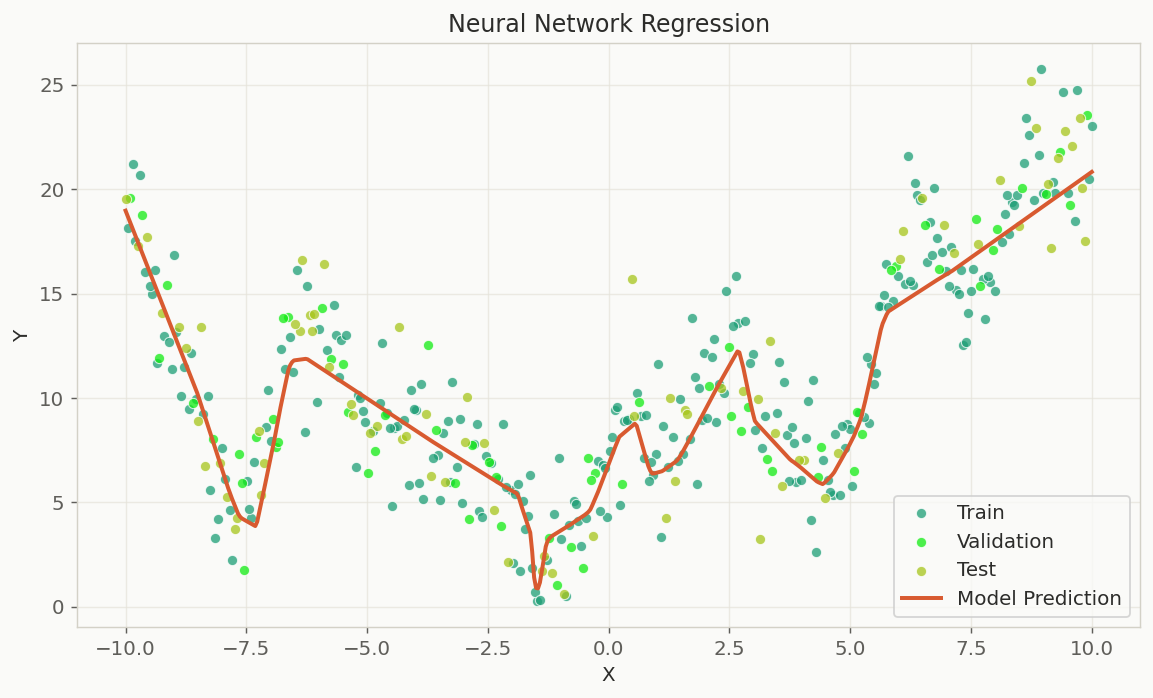

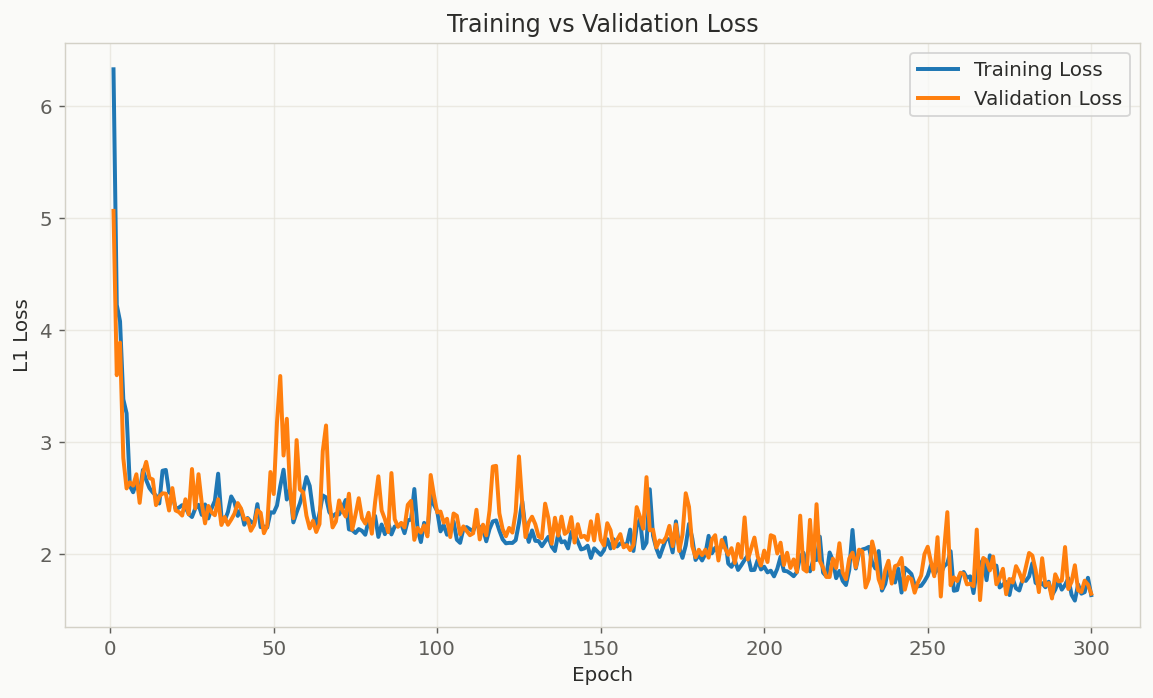

In [18]:



# --------------------------------------------------
# 1. Reproducibility
# --------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)


# --------------------------------------------------
# 2. Create dataset
# --------------------------------------------------
x = np.linspace(-10, 10, 400)

noise = np.random.normal(
    loc=0,
    scale=2.0,
    size=x.shape
)

y = (
    3 * np.sin(x)
    + 2 * np.cos(2 * x)
    + 0.3 * np.abs(x - 2)
    + 0.5 * np.abs(x + 4)
    + 0.8 * np.maximum(x, 0)
    - 0.5 * np.minimum(x, 1)
    + 3 * np.abs(np.sin(0.8 * x))
    + 2 * np.abs(np.cos(1.5 * x))
    + noise
)

X = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
Y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)


# --------------------------------------------------
# 3. Train / Validation / Test split
# --------------------------------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X.numpy(),
    Y.numpy(),
    test_size=0.2,
    random_state=42
)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.2,
    random_state=42
)


# --------------------------------------------------
# 4. Convert to tensors
# --------------------------------------------------
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)


X_train = to_tensor(X_train)
X_val = to_tensor(X_val)
X_test = to_tensor(X_test)

Y_train = to_tensor(Y_train)
Y_val = to_tensor(Y_val)
Y_test = to_tensor(Y_test)


# --------------------------------------------------
# 5. DataLoaders
# --------------------------------------------------
train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=24,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=24,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=24,
    shuffle=False
)


# --------------------------------------------------
# 6. Model
# --------------------------------------------------
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.ReLU(),

    nn.Linear(64, 64),
    nn.ReLU(),

    nn.Linear(64, 64),
    nn.ReLU(),

    nn.Linear(64, 16),
    nn.ReLU(),

    nn.Linear(16, 1)
)


# --------------------------------------------------
# 7. Loss and optimizer
# --------------------------------------------------
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)


# --------------------------------------------------
# 8. Training
# --------------------------------------------------
epochs = 300

# Store losses from every epoch
train_losses = []
val_losses = []


for epoch in range(epochs):

    # ==================================================
    # TRAINING
    # ==================================================
    model.train()

    train_loss = 0.0

    for X_batch, Y_batch in train_loader:

        y_pred = model(X_batch)

        loss = criterion(y_pred, Y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)


    # ==================================================
    # VALIDATION
    # ==================================================
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            y_pred = model(X_batch)

            loss = criterion(y_pred, Y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)


    # ==================================================
    # SAVE LOSSES
    # ==================================================
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    # Print every 20 epochs
    if (epoch + 1) % 20 == 0:

        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Train Loss: {train_loss:.4f} "
            f"- Val Loss: {val_loss:.4f}"
        )


# --------------------------------------------------
# 9. Testing
# --------------------------------------------------
model.eval()

test_loss = 0.0

y_prediction = []
target = []


with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        y_pred = model(X_batch)

        loss = criterion(y_pred, Y_batch)

        test_loss += loss.item() * X_batch.size(0)

        y_prediction.append(y_pred)
        target.append(Y_batch)


test_loss /= len(test_loader.dataset)


# Combine batches
y_prediction = torch.cat(y_prediction)
target = torch.cat(target)


# --------------------------------------------------
# 10. Evaluation metrics
# --------------------------------------------------

mae = torch.mean(
    torch.abs(target - y_prediction)
).item()


mse = torch.mean(
    (target - y_prediction) ** 2
).item()


rmse = mse ** 0.5


print("\nTest Results")
print("-" * 30)
print(f"Test Loss : {test_loss:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")


# --------------------------------------------------
# 11. Plot styling
# --------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "#FAFAF8",
    "axes.facecolor": "#FAFAF8",
    "axes.edgecolor": "#D3D1C7",
    "axes.labelcolor": "#2C2C2A",
    "text.color": "#2C2C2A",
    "xtick.color": "#5F5E5A",
    "ytick.color": "#5F5E5A",
    "font.size": 11,
    "grid.color": "#E5E3DA",
    "grid.linewidth": 0.8,
})


# ==================================================
# GRAPH 1: DATA + MODEL PREDICTION
# ==================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    dpi=130
)


# Training data
ax.scatter(
    X_train,
    Y_train,
    s=32,
    color="#1D9E75",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    label="Train",
    zorder=3
)


# Validation data
ax.scatter(
    X_val,
    Y_val,
    s=32,
    color="#12EC12",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    label="Validation",
    zorder=3
)


# Test data
ax.scatter(
    X_test,
    Y_test,
    s=32,
    color="#A6C51B",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.6,
    label="Test",
    zorder=3
)


# --------------------------------------------------
# Smooth prediction curve
# --------------------------------------------------

X_line = torch.linspace(
    X.min(),
    X.max(),
    500
).reshape(-1, 1)


with torch.no_grad():

    y_line = model(X_line)


ax.plot(
    X_line,
    y_line,
    color="#D85A30",
    linewidth=2.2,
    label="Model Prediction",
    zorder=4
)


ax.set_xlabel("X")
ax.set_ylabel("Y")

ax.set_title("Neural Network Regression")

ax.grid(
    True,
    alpha=0.7
)

ax.legend()

plt.tight_layout()

plt.show()


# ==================================================
# GRAPH 2: TRAINING vs VALIDATION LOSS
# ==================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    dpi=130
)


epochs_range = range(1, epochs + 1)


# Training loss
ax.plot(
    epochs_range,
    train_losses,
    linewidth=2.2,
    label="Training Loss"
)


# Validation loss
ax.plot(
    epochs_range,
    val_losses,
    linewidth=2.2,
    label="Validation Loss"
)


ax.set_xlabel("Epoch")
ax.set_ylabel("L1 Loss")

ax.set_title("Training vs Validation Loss")

ax.grid(
    True,
    alpha=0.7
)

ax.legend()

plt.tight_layout()

plt.show()


Class balance: 200 positives / 400 total
Epoch 20/800 - Train Loss: 0.4543 - Val Loss: 0.4268
Epoch 40/800 - Train Loss: 0.4336 - Val Loss: 0.4357
Epoch 60/800 - Train Loss: 0.4623 - Val Loss: 0.4225
Epoch 80/800 - Train Loss: 0.4340 - Val Loss: 0.3800
Epoch 100/800 - Train Loss: 0.4624 - Val Loss: 0.4252
Epoch 120/800 - Train Loss: 0.4418 - Val Loss: 0.3649
Epoch 140/800 - Train Loss: 0.4265 - Val Loss: 0.3724
Epoch 160/800 - Train Loss: 0.4150 - Val Loss: 0.3536
Epoch 180/800 - Train Loss: 0.3989 - Val Loss: 0.3538
Epoch 200/800 - Train Loss: 0.4292 - Val Loss: 0.3792
Epoch 220/800 - Train Loss: 0.4249 - Val Loss: 0.3505
Epoch 240/800 - Train Loss: 0.4150 - Val Loss: 0.3625
Epoch 260/800 - Train Loss: 0.4213 - Val Loss: 0.3654
Epoch 280/800 - Train Loss: 0.4145 - Val Loss: 0.3533
Epoch 300/800 - Train Loss: 0.4239 - Val Loss: 0.3489
Epoch 320/800 - Train Loss: 0.3929 - Val Loss: 0.3714
Epoch 340/800 - Train Loss: 0.4127 - Val Loss: 0.3500
Epoch 360/800 - Train Loss: 0.4022 - Val Loss

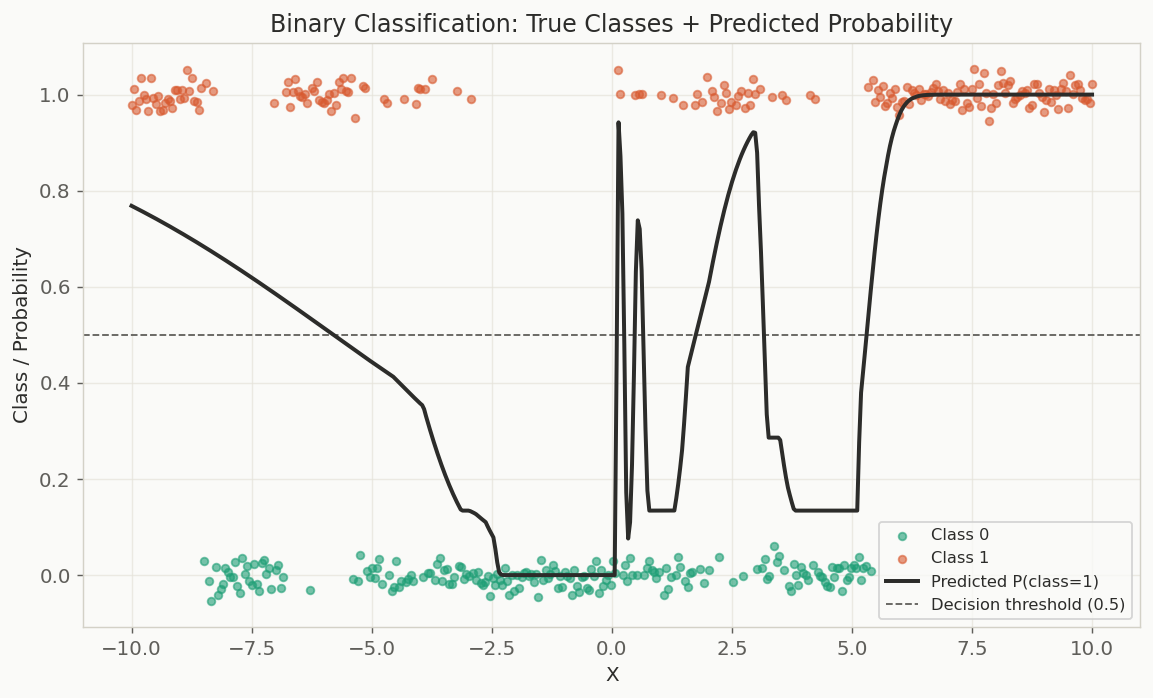

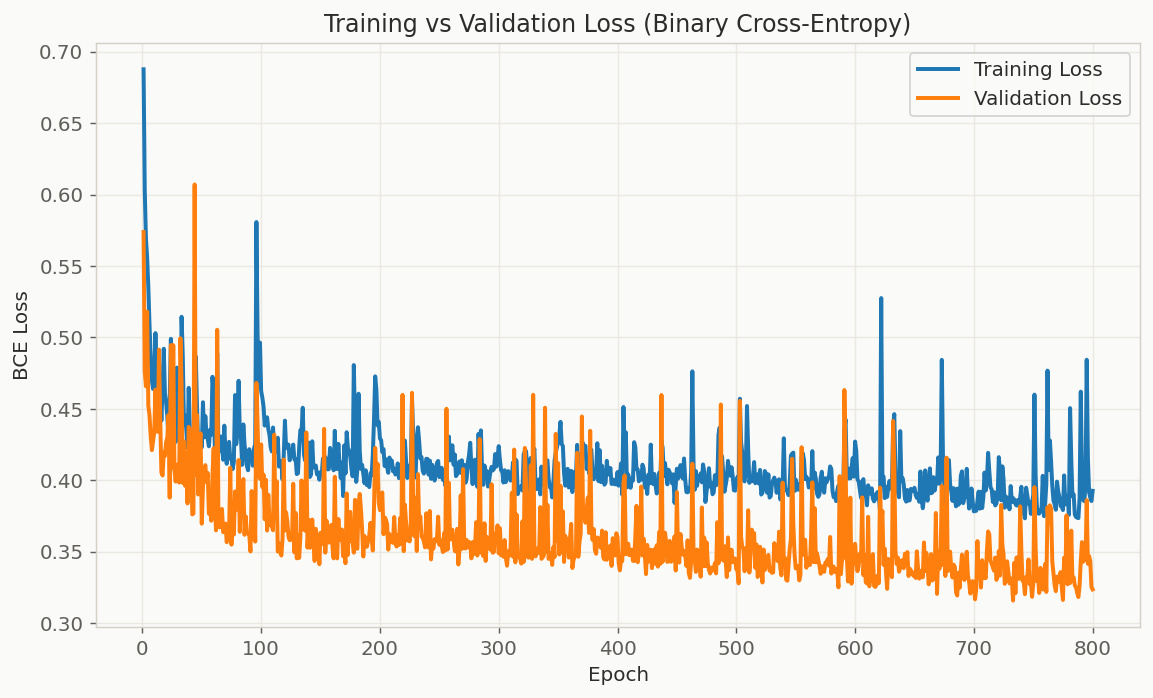

In [29]:
## classification model 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
np.random.seed(42)
torch.manual_seed(42)

# --------------------------------------------------
# 2. Create dataset — SAME feature/function as the regression version,
#    but now thresholded into a binary label at the median.
# --------------------------------------------------
x = np.linspace(-10, 10, 400)

noise = np.random.normal(loc=0, scale=2.0, size=x.shape)

y_continuous = (
    3 * np.sin(x)
    + 2 * np.cos(2 * x)
    + 0.3 * np.abs(x - 2)
    + 0.5 * np.abs(x + 4)
    + 0.8 * np.maximum(x, 0)
    - 0.5 * np.minimum(x, 1)
    + 3 * np.abs(np.sin(0.8 * x))
    + 2 * np.abs(np.cos(1.5 * x))
    + noise
)

# CHANGE 1: threshold the continuous target into a binary label (0/1)
y_label = (y_continuous > np.median(y_continuous)).astype(np.float32)

X = torch.tensor(x, dtype=torch.float32).reshape(-1, 1)
Y = torch.tensor(y_label, dtype=torch.float32).reshape(-1, 1)

print(f"Class balance: {int(y_label.sum())} positives / {len(y_label)} total")

# --------------------------------------------------
# 3. Train / Validation / Test split
#    CHANGE 2: stratify=... keeps class proportions balanced in every split
# --------------------------------------------------
X_temp, X_test, Y_temp, Y_test = train_test_split(
    X.numpy(), Y.numpy(), test_size=0.2, random_state=42, stratify=Y.numpy()
)

X_train, X_val, Y_train, Y_val = train_test_split(
    X_temp, Y_temp, test_size=0.2, random_state=42, stratify=Y_temp
)


def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)


X_train, X_val, X_test = to_tensor(X_train), to_tensor(X_val), to_tensor(X_test)
Y_train, Y_val, Y_test = to_tensor(Y_train), to_tensor(Y_val), to_tensor(Y_test)

# --------------------------------------------------
# 4. DataLoaders — UNCHANGED
# --------------------------------------------------
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=12, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=12, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=12, shuffle=False)

# --------------------------------------------------
# 5. Model — IDENTICAL architecture to the regression version.
#    No Sigmoid at the end: BCEWithLogitsLoss expects raw logits.
# --------------------------------------------------
model = nn.Sequential(
    nn.Linear(1, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 16), nn.ReLU(),
    nn.Linear(16, 1),
)

# --------------------------------------------------
# 6. Loss and optimizer
#    CHANGE 3: this is the one line that matters most.
# --------------------------------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# --------------------------------------------------
# 7. Training — UNCHANGED mechanics
# --------------------------------------------------
epochs = 800
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch, Y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, Y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, Y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

# --------------------------------------------------
# 8. Testing
#    CHANGE 4: raw output -> sigmoid -> probability -> threshold -> class
# --------------------------------------------------
model.eval()
test_loss = 0.0
y_prediction, target = [], []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, Y_batch)
        test_loss += loss.item() * X_batch.size(0)

        y_prediction.append(y_pred)
        target.append(Y_batch)

test_loss /= len(test_loader.dataset)

y_prediction = torch.cat(y_prediction)   # raw logits
target = torch.cat(target)

probs = torch.sigmoid(y_prediction)              # logits -> probabilities
preds = (probs > 0.5).float()                    # probabilities -> class labels

# --------------------------------------------------
# 9. Evaluation metrics
#    CHANGE 5: classification metrics instead of MAE/MSE/RMSE/R²
# --------------------------------------------------
acc = accuracy_score(target.numpy(), preds.numpy())
prec = precision_score(target.numpy(), preds.numpy())
rec = recall_score(target.numpy(), preds.numpy())
f1 = f1_score(target.numpy(), preds.numpy())
cm = confusion_matrix(target.numpy(), preds.numpy())

print("\nTest Results")
print("-" * 30)
print(f"Test Loss (BCE) : {test_loss:.4f}")
print(f"Accuracy        : {acc:.4f}")
print(f"Precision       : {prec:.4f}")
print(f"Recall          : {rec:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")

# --------------------------------------------------
# 10. Plot styling
# --------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "#FAFAF8", "axes.facecolor": "#FAFAF8",
    "axes.edgecolor": "#D3D1C7", "axes.labelcolor": "#2C2C2A",
    "text.color": "#2C2C2A", "xtick.color": "#5F5E5A", "ytick.color": "#5F5E5A",
    "font.size": 11, "grid.color": "#E5E3DA", "grid.linewidth": 0.8,
})

# ==================================================
# GRAPH 1: classes + predicted probability curve (the decision boundary)
# ==================================================
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=130)

x_all = np.concatenate([X_train.numpy(), X_val.numpy(), X_test.numpy()]).flatten()
y_all = np.concatenate([Y_train.numpy(), Y_val.numpy(), Y_test.numpy()]).flatten()
jitter = np.random.normal(0, 0.02, size=y_all.shape)   # jitter for visibility only

ax.scatter(x_all[y_all == 0], y_all[y_all == 0] + jitter[y_all == 0],
           s=18, color="#1D9E75", alpha=0.6, label="Class 0", zorder=3)
ax.scatter(x_all[y_all == 1], y_all[y_all == 1] + jitter[y_all == 1],
           s=18, color="#D85A30", alpha=0.6, label="Class 1", zorder=3)

X_line = torch.linspace(X.min(), X.max(), 500).reshape(-1, 1)
with torch.no_grad():
    probs_line = torch.sigmoid(model(X_line))

ax.plot(X_line, probs_line, color="#2C2C2A", linewidth=2.2, label="Predicted P(class=1)", zorder=4)
ax.axhline(0.5, color="#5F5E5A", linestyle="--", linewidth=1, label="Decision threshold (0.5)")

ax.set_xlabel("X")
ax.set_ylabel("Class / Probability")
ax.set_title("Binary Classification: True Classes + Predicted Probability")
ax.grid(True, alpha=0.7)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ==================================================
# GRAPH 2: training vs validation loss
# ==================================================
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=130)
ax.plot(range(1, epochs + 1), train_losses, linewidth=2.2, label="Training Loss")
ax.plot(range(1, epochs + 1), val_losses, linewidth=2.2, label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Training vs Validation Loss (Binary Cross-Entropy)")
ax.grid(True, alpha=0.7)
ax.legend()
plt.tight_layout()


plt.show()

